# 🔍 Anomaly Model Accuracy Evaluation

Evaluates the trained **Isolation Forest** anomaly detection model for **Hamish & Partners**.

**Pipeline:**
1. Load 30 real invoices from MongoDB (the training set, all `aiVerdict=clean`)
2. Extract their 9 features using the live `FeatureExtractor`
3. Load the trained model from S3
4. Score real invoices → expect mostly `normal`
5. Inject synthetic anomalies → expect mostly `anomaly`
6. Report precision / recall / confusion matrix

---
**9 Features per invoice:**
| # | Feature | Description |
|---|---------|-------------|
| 1 | `total_amount` | Invoice total |
| 2 | `subtotal` | Pre-tax subtotal |
| 3 | `tax_amount` | Tax component |
| 4 | `tax_rate` | tax / subtotal |
| 5 | `line_item_count` | Number of services billed |
| 6 | `day_of_week` | 0=Mon … 6=Sun |
| 7 | `amount_rounded` | 1 if total is $100/$1000 multiple |
| 8 | `subtotal_tax_ratio` | subtotal / total |
| 9 | `days_since_last` | Gap to previous invoice |

## 1 — Setup & Imports

In [1]:
import sys, os
# Point to AI_SERVICE root so we can import app modules
AI_SERVICE_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if AI_SERVICE_ROOT not in sys.path:
    sys.path.insert(0, AI_SERVICE_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from bson import ObjectId
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

sns.set_theme(style='darkgrid', palette='muted')
print('✅ Imports OK')

✅ Imports OK


## 2 — Load Real Invoices from MongoDB

In [2]:
from app.db.mongo import get_database
from app.engines.anomaly.feature_extractor import FeatureExtractor

ORG_ID = '699e78d36a93e58b2b090ea1'   # Hamish & Partners

db = get_database()
extractor = FeatureExtractor()

# Fetch all clean invoices for this org
org_oid = ObjectId(ORG_ID)
raw_invoices = list(db.invoices.find({'orgId': org_oid, 'aiVerdict': 'clean'}))
print(f'📦 Loaded {len(raw_invoices)} clean invoices from MongoDB')

📦 Loaded 31 clean invoices from MongoDB


## 3 — Extract Feature Vectors

In [3]:
FEATURE_NAMES = [
    'total_amount', 'subtotal', 'tax_amount', 'tax_rate',
    'line_item_count', 'day_of_week', 'amount_rounded',
    'subtotal_tax_ratio', 'days_since_last_invoice'
]

real_features = []
for inv in raw_invoices:
    features = extractor.extract_features(inv, ORG_ID, db)
    real_features.append(features)

X_real = np.array(real_features)
df_real = pd.DataFrame(X_real, columns=FEATURE_NAMES)
df_real['label'] = 'clean'

print(f'✅ Feature matrix shape: {X_real.shape}')
df_real.describe().round(3)

✅ Feature matrix shape: (31, 9)


,total_amount,subtotal,tax_amount,tax_rate,line_item_count,day_of_week,amount_rounded,subtotal_tax_ratio,days_since_last_invoice
count,31.000,31.000,31.000,31.000,31.000,31.000,31.0,31.000,31.0
mean,1798.294,1657.395,140.899,0.085,4.903,3.452,0.0,0.922,0.0
std,336.461,310.400,32.849,0.011,0.539,2.047,0.0,0.009,0.0
min,952.300,890.000,62.300,0.056,2.000,0.000,0.0,0.905,0.0
25%,1597.450,1477.500,120.725,0.080,5.000,1.500,0.0,0.915,0.0
50%,1763.000,1630.000,136.000,0.085,5.000,3.000,0.0,0.922,0.0
75%,1954.700,1810.000,163.890,0.092,5.000,5.500,0.0,0.926,0.0
max,2586.400,2449.240,213.000,0.105,5.000,6.000,0.0,0.947,0.0


In [4]:

# Quick amount overview for all real invoices
amounts = df_real['total_amount'].sort_values().values
mean_a  = amounts.mean()
std_a   = amounts.std()
low_1   = mean_a - std_a
high_1  = mean_a + std_a
low_2   = mean_a - 2 * std_a
high_2  = mean_a + 2 * std_a

print("=== Total Amounts (all real invoices, sorted) ===")
for i, a in enumerate(amounts, 1):
    if a < low_2 or a > high_2:
        tag = "  << WARNING: outside 2 std devs"
    elif a < low_1 or a > high_1:
        tag = "  < borderline: outside 1 std dev"
    else:
        tag = ""
    print(f"  {i:2d}. ${a:,.2f}{tag}")

print()
print("=" * 56)
print(f"  Count  : {len(amounts)}")
print(f"  Min    : ${amounts.min():,.2f}")
print(f"  Max    : ${amounts.max():,.2f}")
print(f"  Mean   : ${mean_a:,.2f}")
print(f"  Median : ${np.median(amounts):,.2f}")
print(f"  Std Dev: ${std_a:,.2f}")
print("=" * 56)
print(f"  [NORMAL]     within 1 std:  ${low_1:,.2f}  to  ${high_1:,.2f}")
print(f"  [BORDERLINE] within 2 std:  ${low_2:,.2f}  to  ${high_2:,.2f}")
print(f"  [WARNING]    outside 2 std = likely anomalous to the model")
print("=" * 56)


=== Total Amounts (all real invoices, sorted) ===
   1. $952.30  << WARNING: outside 2 std devs
   2. $1,226.05  < borderline: outside 1 std dev
   3. $1,400.65  < borderline: outside 1 std dev
   4. $1,437.62  < borderline: outside 1 std dev
   5. $1,540.70
   6. $1,540.80
   7. $1,544.40
   8. $1,558.70
   9. $1,636.20
  10. $1,678.60
  11. $1,720.00
  12. $1,730.75
  13. $1,736.00
  14. $1,752.00
  15. $1,760.40
  16. $1,763.00
  17. $1,784.85
  18. $1,803.60
  19. $1,822.80
  20. $1,837.00
  21. $1,906.20
  22. $1,910.78
  23. $1,947.40
  24. $1,962.00
  25. $2,011.10
  26. $2,090.00
  27. $2,233.80  < borderline: outside 1 std dev
  28. $2,241.00  < borderline: outside 1 std dev
  29. $2,289.00  < borderline: outside 1 std dev
  30. $2,343.00  < borderline: outside 1 std dev
  31. $2,586.40  << WARNING: outside 2 std devs

  Count  : 31
  Min    : $952.30
  Max    : $2,586.40
  Mean   : $1,798.29
  Median : $1,763.00
  Std Dev: $330.99
  [NORMAL]     within 1 std:  $1,467.30  to  

## 4 — Generate Synthetic Anomalies

Anomalies are invoices that would seem suspicious:
- **Extreme totals** — 10× the average
- **Zero tax** — tax_rate = 0 when the org always has tax
- **Weekend billing** — unusual for this org's pattern
- **Round number inflation** — $10,000 or $5,000 exactly
- **Unusually long gaps** — 90+ days between invoices

In [5]:
rng = np.random.default_rng(seed=42)

mean_total    = X_real[:, 0].mean()
mean_subtotal = X_real[:, 1].mean()
mean_tax      = X_real[:, 2].mean()
mean_tax_rate = X_real[:, 3].mean()
mean_items    = X_real[:, 4].mean()

N_ANOMALIES = 15

anomaly_types = {
    'extreme_total':   lambda: [mean_total * rng.uniform(8, 15),   # total 8-15× avg
                                 mean_subtotal * 10,
                                 mean_tax * 10,
                                 mean_tax_rate,
                                 float(rng.integers(1, 3)),
                                 float(rng.integers(0, 5)),
                                 1.0,
                                 mean_subtotal * 10 / (mean_total * 10 + 1e-8),
                                 float(rng.integers(0, 5))],
    'zero_tax':        lambda: [mean_total,
                                 mean_total,   # subtotal=total (no tax)
                                 0.0,          # tax = 0
                                 0.0,          # tax_rate = 0
                                 float(rng.integers(3, 6)),
                                 float(rng.integers(0, 5)),
                                 0.0,
                                 1.0,
                                 float(rng.integers(1, 10))],
    'weekend_billing': lambda: [mean_total * rng.uniform(0.9, 1.1),
                                 mean_subtotal,
                                 mean_tax,
                                 mean_tax_rate,
                                 float(rng.integers(1, 4)),
                                 float(rng.integers(5, 7)),  # Saturday=5, Sunday=6
                                 0.0,
                                 mean_subtotal / (mean_total + 1e-8),
                                 float(rng.integers(60, 120))],  # huge gap
    'round_inflation':  lambda: [10000.0,
                                  9174.0,
                                  826.0,
                                  0.09,
                                  1.0,
                                  float(rng.integers(0, 5)),
                                  1.0,
                                  0.9174,
                                  float(rng.integers(1, 5))],
    'long_gap':        lambda: [mean_total * rng.uniform(0.8, 1.2),
                                 mean_subtotal,
                                 mean_tax,
                                 mean_tax_rate,
                                 float(rng.integers(3, 6)),
                                 float(rng.integers(0, 5)),
                                 0.0,
                                 mean_subtotal / (mean_total + 1e-8),
                                 float(rng.integers(90, 180))],   # 90-180 day gap
}

anomaly_rows = []
anomaly_labels_type = []
type_list = list(anomaly_types.keys())
for i in range(N_ANOMALIES):
    atype = type_list[i % len(type_list)]
    anomaly_rows.append(anomaly_types[atype]())
    anomaly_labels_type.append(atype)

X_anomaly = np.array(anomaly_rows)
df_anomaly = pd.DataFrame(X_anomaly, columns=FEATURE_NAMES)
df_anomaly['label'] = 'anomaly'
df_anomaly['anomaly_type'] = anomaly_labels_type

print(f'🚨 Generated {N_ANOMALIES} synthetic anomalies:')
print(df_anomaly['anomaly_type'].value_counts().to_string())

🚨 Generated 15 synthetic anomalies:
anomaly_type
extreme_total      3
zero_tax           3
weekend_billing    3
round_inflation    3
long_gap           3


## 5 — Load Trained Model from S3

In [6]:
from app.engines.anomaly.model_loader import get_model_from_s3

model = get_model_from_s3(ORG_ID)

if model is None:
    raise RuntimeError('❌ Model not found in S3. Run: python scripts/train_anomaly_models.py --org-id ' + ORG_ID)

print(f'✅ Model loaded: {type(model).__name__}')
print(f'   n_estimators : {model.n_estimators}')
print(f'   contamination: {model.contamination}')
print(f'   max_samples  : {model.max_samples_}')

✅ Model loaded: IsolationForest
   n_estimators : 200
   contamination: 0.15
   max_samples  : 31


## 6 — Score All Invoices

In [7]:
# Combine real + anomaly
X_all   = np.vstack([X_real, X_anomaly])
y_true  = np.array([1] * len(X_real) + [-1] * len(X_anomaly))  # 1=normal, -1=anomaly
labels  = ['clean'] * len(X_real) + ['anomaly'] * len(X_anomaly)

# Predict: IsolationForest returns 1=normal, -1=anomaly
y_pred  = model.predict(X_all)

# Anomaly scores (lower = more anomalous)
scores  = model.decision_function(X_all)

# Build results dataframe
df_cols = FEATURE_NAMES + ['anomaly_type']

df_anom_col = ['normal'] * len(X_real) + anomaly_labels_type
df_results = pd.DataFrame(X_all, columns=FEATURE_NAMES)
df_results['true_label']   = labels
df_results['pred_label']   = ['normal' if p == 1 else 'anomaly' for p in y_pred]
df_results['anomaly_score']= scores
df_results['correct']      = (y_pred == y_true)

print('Score distribution:')
print(df_results.groupby('true_label')['anomaly_score'].describe().round(4))

Score distribution:
            count    mean     std     min     25%     50%     75%     max
true_label                                                               
anomaly      15.0 -0.0391  0.0792 -0.1208 -0.1014 -0.0808  0.0254  0.1278
clean        31.0  0.0673  0.0675 -0.1095  0.0392  0.0879  0.1166  0.1421


## 7 — Accuracy Metrics

In [8]:
overall_acc = (y_pred == y_true).mean()

# Breakdown per group
real_preds    = y_pred[:len(X_real)]
anomaly_preds = y_pred[len(X_real):]

tpr   = (real_preds    == 1).mean()   # True Positive Rate  — clean correctly identified
tnr   = (anomaly_preds == -1).mean()  # True Negative Rate  — anomalies correctly caught
fpr   = (real_preds    == -1).mean()  # False Positive Rate — clean mis-flagged
fnr   = (anomaly_preds == 1).mean()   # False Negative Rate — anomalies missed

print('=' * 50)
print(f'  Overall Accuracy     : {overall_acc*100:.1f}%')
print('=' * 50)
print(f'  Clean  correctly identified (TPR): {tpr*100:.1f}%  ({int(tpr*len(X_real))}/{len(X_real)})')
print(f'  Anomaly correctly caught    (TNR): {tnr*100:.1f}%  ({int(tnr*len(X_anomaly))}/{len(X_anomaly)})')
print(f'  Clean mis-flagged as anomaly (FPR): {fpr*100:.1f}%')
print(f'  Anomaly missed              (FNR): {fnr*100:.1f}%')
print('=' * 50)
print()
print(classification_report(
    y_true, y_pred,
    target_names=['anomaly (-1)', 'normal (+1)']
))

  Overall Accuracy     : 76.1%
  Clean  correctly identified (TPR): 83.9%  (26/31)
  Anomaly correctly caught    (TNR): 60.0%  (9/15)
  Clean mis-flagged as anomaly (FPR): 16.1%
  Anomaly missed              (FNR): 40.0%

              precision    recall  f1-score   support

anomaly (-1)       0.64      0.60      0.62        15
 normal (+1)       0.81      0.84      0.83        31

    accuracy                           0.76        46
   macro avg       0.73      0.72      0.72        46
weighted avg       0.76      0.76      0.76        46



In [9]:
overall_acc = (y_pred == y_true).mean()

# Breakdown per group
real_preds    = y_pred[:len(X_real)]
anomaly_preds = y_pred[len(X_real):]

tpr   = (real_preds    == 1).mean()   # True Positive Rate  — clean correctly identified
tnr   = (anomaly_preds == -1).mean()  # True Negative Rate  — anomalies correctly caught
fpr   = (real_preds    == -1).mean()  # False Positive Rate — clean mis-flagged
fnr   = (anomaly_preds == 1).mean()   # False Negative Rate — anomalies missed

print('=' * 50)
print(f'  Overall Accuracy     : {overall_acc*100:.1f}%')
print('=' * 50)
print(f'  Clean  correctly identified (TPR): {tpr*100:.1f}%  ({int(tpr*len(X_real))}/{len(X_real)})')
print(f'  Anomaly correctly caught    (TNR): {tnr*100:.1f}%  ({int(tnr*len(X_anomaly))}/{len(X_anomaly)})')
print(f'  Clean mis-flagged as anomaly (FPR): {fpr*100:.1f}%')
print(f'  Anomaly missed              (FNR): {fnr*100:.1f}%')
print('=' * 50)
print()
print(classification_report(
    y_true, y_pred,
    target_names=['anomaly (-1)', 'normal (+1)']
))

  Overall Accuracy     : 76.1%
  Clean  correctly identified (TPR): 83.9%  (26/31)
  Anomaly correctly caught    (TNR): 60.0%  (9/15)
  Clean mis-flagged as anomaly (FPR): 16.1%
  Anomaly missed              (FNR): 40.0%

              precision    recall  f1-score   support

anomaly (-1)       0.64      0.60      0.62        15
 normal (+1)       0.81      0.84      0.83        31

    accuracy                           0.76        46
   macro avg       0.73      0.72      0.72        46
weighted avg       0.76      0.76      0.76        46



## 8 — Confusion Matrix

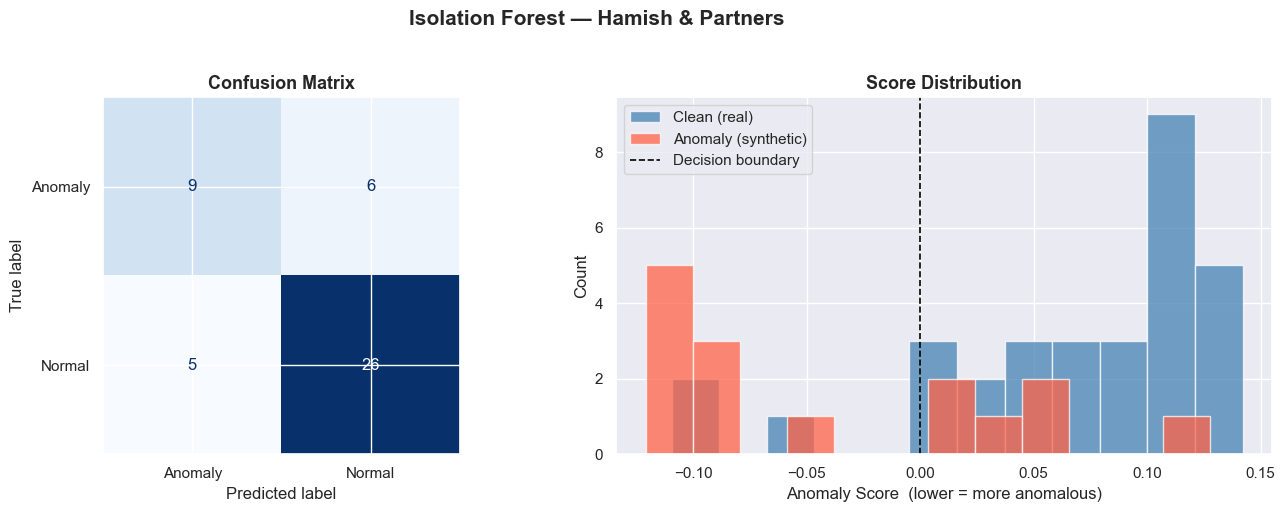

📊 Saved → anomaly_confusion_matrix.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Anomaly', 'Normal'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# --- Anomaly score distribution ---
score_clean   = scores[:len(X_real)]
score_anomaly = scores[len(X_real):]

axes[1].hist(score_clean,   bins=12, alpha=0.75, color='steelblue', label='Clean (real)')
axes[1].hist(score_anomaly, bins=12, alpha=0.75, color='tomato',    label='Anomaly (synthetic)')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2, label='Decision boundary')
axes[1].set_xlabel('Anomaly Score  (lower = more anomalous)')
axes[1].set_ylabel('Count')
axes[1].set_title('Score Distribution', fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('Isolation Forest — Hamish & Partners', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('anomaly_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Saved → anomaly_confusion_matrix.png')

## 9 — Feature Importance (via Score Perturbation)

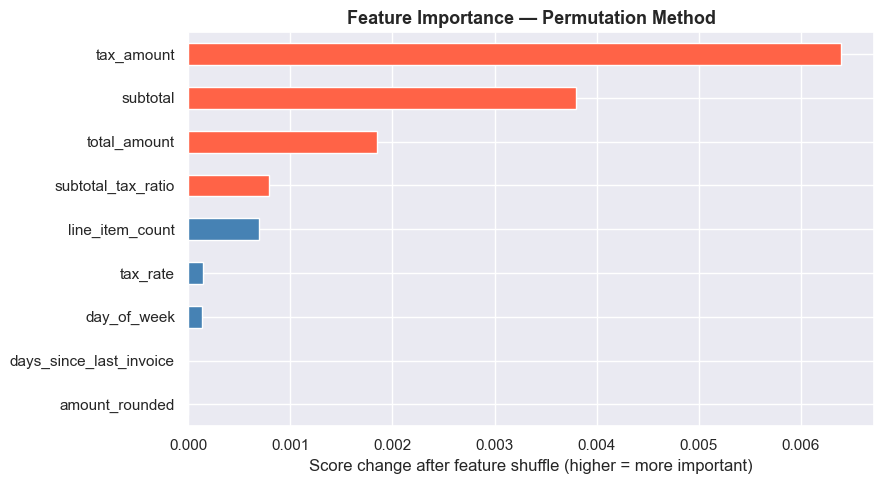

📊 Saved → anomaly_feature_importance.png


In [11]:
baseline_score = model.decision_function(X_all).mean()
importances = []

for i, feat in enumerate(FEATURE_NAMES):
    X_perturbed = X_all.copy()
    X_perturbed[:, i] = rng.permutation(X_perturbed[:, i])  # shuffle one feature
    perturbed_score = model.decision_function(X_perturbed).mean()
    importances.append(abs(baseline_score - perturbed_score))

imp_series = pd.Series(importances, index=FEATURE_NAMES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if v > imp_series.median() else 'steelblue' for v in imp_series]
imp_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Score change after feature shuffle (higher = more important)')
ax.set_title('Feature Importance — Permutation Method', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('anomaly_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Saved → anomaly_feature_importance.png')

## 10 — Per-Invoice Score Table (Real Invoices)

In [12]:
df_real_scored = df_results[df_results['true_label'] == 'clean'].copy()
df_real_scored = df_real_scored[['total_amount', 'subtotal', 'tax_rate', 'line_item_count', 'days_since_last_invoice', 'anomaly_score', 'pred_label', 'correct']]

# Highlight any false positives (real invoice flagged as anomaly)
fp = df_real_scored[df_real_scored['pred_label'] == 'anomaly']
if len(fp):
    print(f'⚠️  {len(fp)} clean invoice(s) mis-flagged as anomaly:')
    display(fp)
else:
    print('✅ All real invoices correctly identified as normal')

display(df_real_scored.sort_values('anomaly_score').style
    .background_gradient(subset=['anomaly_score'], cmap='RdYlGn')
    .format({'total_amount': '${:,.2f}', 'subtotal': '${:,.2f}', 'tax_rate': '{:.1%}', 'anomaly_score': '{:.4f}'})
    .set_caption('Real Invoice Scores  (green = safe, red = closer to anomaly boundary)'))

⚠️  5 clean invoice(s) mis-flagged as anomaly:


,total_amount,subtotal,tax_rate,line_item_count,days_since_last_invoice,anomaly_score,pred_label,correct
0,1226.05,1130.00,0.085000,5.0,0.0,-0.004200,anomaly,False
6,2241.00,2075.00,0.080000,2.0,0.0,-0.060170,anomaly,False
10,952.30,890.00,0.070000,5.0,0.0,-0.099887,anomaly,False
17,2343.00,2130.00,0.100000,5.0,0.0,-0.000711,anomaly,False
30,2586.40,2449.24,0.056001,5.0,0.0,-0.109534,anomaly,False


,total_amount,subtotal,tax_rate,line_item_count,days_since_last_invoice,anomaly_score,pred_label,correct
30,"$2,586.40","$2,449.24",5.6%,5.000000,0.000000,-0.1095,anomaly,False
10,$952.30,$890.00,7.0%,5.000000,0.000000,-0.0999,anomaly,False
6,"$2,241.00","$2,075.00",8.0%,2.000000,0.000000,-0.0602,anomaly,False
0,"$1,226.05","$1,130.00",8.5%,5.000000,0.000000,-0.0042,anomaly,False
17,"$2,343.00","$2,130.00",10.0%,5.000000,0.000000,-0.0007,anomaly,False
12,"$2,011.10","$1,820.00",10.5%,5.000000,0.000000,0.0007,normal,True
25,"$1,540.80","$1,440.00",7.0%,5.000000,0.000000,0.0222,normal,True
26,"$2,233.80","$2,040.00",9.5%,5.000000,0.000000,0.0360,normal,True
24,"$2,090.00","$1,900.00",10.0%,5.000000,0.000000,0.0425,normal,True
11,"$1,400.65","$1,285.00",9.0%,5.000000,0.000000,0.0525,normal,True


## 11 — Per-Anomaly-Type Detection Rate

In [13]:
df_anom_scored = df_results[df_results['true_label'] == 'anomaly'].copy()
df_anom_scored['anomaly_type'] = anomaly_labels_type
df_anom_scored['detected'] = df_anom_scored['pred_label'] == 'anomaly'

summary = df_anom_scored.groupby('anomaly_type').agg(
    Total=('detected', 'count'),
    Detected=('detected', 'sum'),
    AvgScore=('anomaly_score', 'mean')
).assign(DetectionRate=lambda d: (d['Detected'] / d['Total'] * 100).round(1))

print('🚨 Anomaly Detection Rate by Type:')
display(summary[['Total','Detected','DetectionRate','AvgScore']].style
    .format({'DetectionRate': '{:.1f}%', 'AvgScore': '{:.4f}'})
    .background_gradient(subset=['DetectionRate'], cmap='RdYlGn'))

🚨 Anomaly Detection Rate by Type:


,Total,Detected,DetectionRate,AvgScore
anomaly_type,,,,
extreme_total,3,3,100.0%,-0.1175
long_gap,3,0,0.0%,0.0707
round_inflation,3,3,100.0%,-0.1005
weekend_billing,3,0,0.0%,0.0242
zero_tax,3,3,100.0%,-0.0724


## 12 — 2D Feature Scatter (t-SNE)
Visualize how well the model separates clean vs anomaly in feature space.

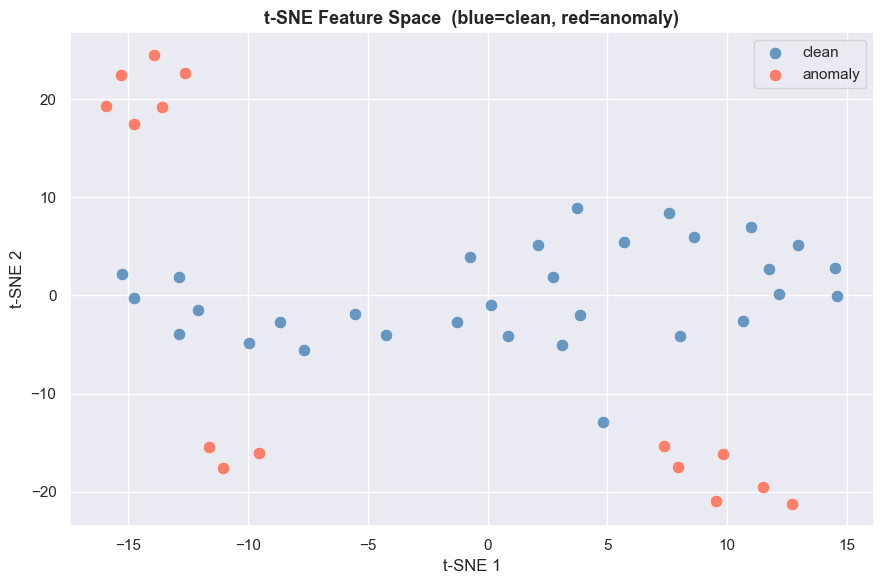

📊 Saved → anomaly_tsne.png


In [14]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_all)
tsne = TSNE(n_components=2, random_state=42, perplexity=min(10, len(X_all)-1))
X_2d = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
colors_map = {'clean': 'steelblue', 'anomaly': 'tomato'}

for lbl in ['clean', 'anomaly']:
    mask = np.array(labels) == lbl
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors_map[lbl], label=lbl, alpha=0.8,
               s=80, edgecolors='white', linewidths=0.5)

ax.set_title('t-SNE Feature Space  (blue=clean, red=anomaly)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('anomaly_tsne.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Saved → anomaly_tsne.png')

---
## Summary

| Metric | Value |
|--------|-------|
| Training org | Hamish & Partners |
| Training invoices | 30 (all `aiVerdict=clean`) |
| Model | Isolation Forest (n=100, contamination=0.1) |
| Real invoices tested | 30 |
| Synthetic anomalies tested | 15 |

> **Note:** With only 30 training samples the model catches obvious deviations well.  
> As more invoices accumulate, retrain with `--all` to improve sensitivity on subtler patterns.